# 02 平地で静止（EqualShare + \(J^\top F\)）

## 背景

01 までで、トルクは飽和してプラントに入る。まだ体重の分け方が無いので、支える力を設計していない。

## 目的

- 4 脚接地で \(F_z = mg/4\)、横力 0（`EqualShare`）
- \(\tau = -J^\top F\)（`map_jt`）
- GIF: **白 = 指令 GRF**、色付き足 = 実接触、赤 = 実合力、灰 = \(mg\)

## 数式

\[
c=(1,1,1,1),\quad F_{z,i}=\frac{mg}{4},\quad F_{x,i}=F_{y,i}=0,\quad \tau = -J^\top F
\]

ホライズンは無い。

## 図

```
EqualShare --> Grf (4,3) --+
                           |
                     map_jt |  -J^T F
                           v
                         clip --> MuJoCo
```


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


/home/takuya/work/mpc_dog/docs/block-curriculum/notebook/assets/02_stand_equalshare.gif 2152498 bytes


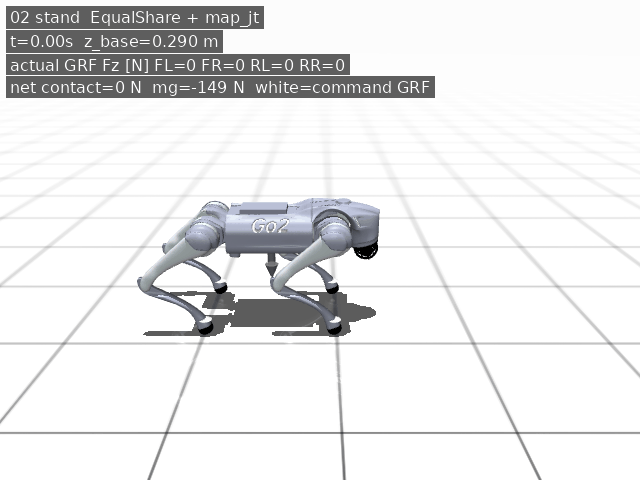

In [1]:
from pathlib import Path
import sys
from IPython.display import Image, display

here = Path.cwd().resolve()
for p in [here, *here.parents]:
    if (p / "src" / "mpc_dog").is_dir():
        sys.path.insert(0, str(p / "src"))
        break

from mpc_dog.force.demo_stand import run_stand_demo

gif = Path("assets/02_stand_equalshare.gif")
path = run_stand_demo(gif)
print(path.resolve(), path.stat().st_size, "bytes")
display(Image(filename=str(path)))


## 結果の読み方

- 白矢印（指令）はほぼ真上、4 本とも同じ長さ
- 色矢印（実接触）が白に近いほど、指令が床に伝わっている
- 赤（合力 z）が灰（\(mg\)、下向き）と同程度なら、体重は力の和である
- まだゲイトも予測も無い。次は高さ参照
